# Swin Tiny for Diabetic Retinopathy Grading

This notebook fine-tunes a pretrained Swin Tiny Transformer to classify retinal fundus images into five diabetic retinopathy severity grades. The workflow covers dependency setup, exploratory visualisation, stratified data splitting, imbalance handling, model training, and final evaluation.


In [1]:
# ============================================================
# CELL 1 — Install dependencies
# ============================================================
# Run this cell first, then restart kernel
import subprocess
subprocess.run(["pip", "install", "torch", "torchvision", "torchaudio",
                "--index-url", "https://download.pytorch.org/whl/cu128"])
subprocess.run(["pip", "install", "transformers", "timm", "scikit-learn",
                "pandas", "numpy", "matplotlib", "seaborn", "opencv-python",
                "pillow", "tqdm", "grad-cam"])

Looking in indexes: https://download.pytorch.org/whl/cu128


CompletedProcess(args=['pip', 'install', 'transformers', 'timm', 'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'opencv-python', 'pillow', 'tqdm', 'grad-cam'], returncode=0)

## Imports

The required libraries include PyTorch for model training, Hugging Face Transformers for the pretrained Swin Tiny model, scikit-learn for stratified splitting and evaluation metrics, and plotting libraries for result visualisation.


In [15]:
# ============================================================
# CELL 2 — Imports
# ============================================================
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
from torch.amp import autocast, GradScaler
from torchvision import transforms

from transformers import SwinForImageClassification

from sklearn.metrics import (
    cohen_kappa_score, confusion_matrix, classification_report,
    f1_score, roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from tqdm import tqdm

print("All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

All imports successful!
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA RTX A4000


## Configuration and Reproducibility

This section defines paths, hyperparameters, class labels, device selection, output folders, and random seeds. Keeping these settings together makes the experiment easier to reproduce and modify.


In [3]:
# ============================================================
# CELL 3 — Configuration
# Model: Swin Tiny 224
# ============================================================

# ── Paths ─────────────────────────────────────────────────────
CSV_PATH   = "data/raw/trainLabels.csv"
IMAGE_DIR  = "data/processed"
OUTPUT_DIR = "outputs_final"

# ── Fixed settings — same for all group members ───────────────
SEED            = 42
IMAGE_SIZE      = 224
BATCH_SIZE      = 32
NUM_EPOCHS      = 30
LR_BACKBONE     = 3e-6    # backbone learning rate
LR_HEAD         = 3e-5    # classifier head learning rate
WEIGHT_DECAY    = 0.01
VAL_SPLIT       = 0.15
NUM_WORKERS     = 8       
LABEL_SMOOTHING = 0.1
PATIENCE        = 7       # early stopping patience
ACCUMULATION    = 2       # gradient accumulation steps

# ── Class info ────────────────────────────────────────────────
CLASS_NAMES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]
NUM_CLASSES = 5

# ── Device ────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Reproducibility ───────────────────────────────────────────
import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/plots", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/checkpoints", exist_ok=True)

print(f"Device: {device}")


Device: cuda


## Dataset Class Distribution

Before training, the label distribution is inspected to understand class imbalance. This is important because diabetic retinopathy datasets usually contain many more No DR examples than severe disease examples.


Total images: 35126
Columns: ['image', 'level']
      image  level
0   10_left      0
1  10_right      0
2   13_left      0
3  13_right      0
4   15_left      1

Class distribution:
  Class 0 (No DR): 25810 images (73.5%)
  Class 1 (Mild): 2443 images (7.0%)
  Class 2 (Moderate): 5292 images (15.1%)
  Class 3 (Severe): 873 images (2.5%)
  Class 4 (Proliferative): 708 images (2.0%)


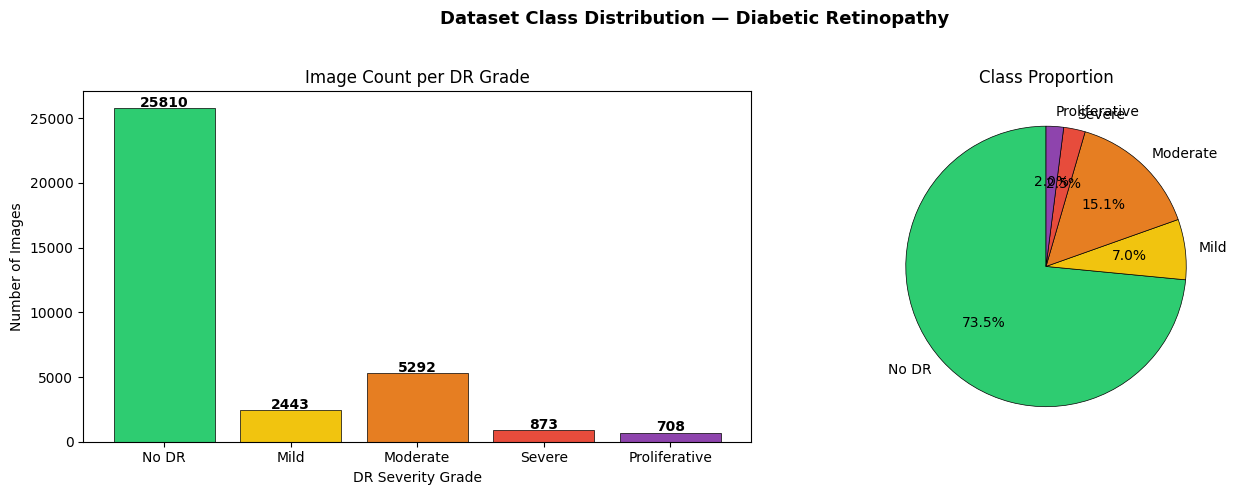

Class distribution plot saved!


In [4]:
# ============================================================
# CELL 4 — Dataset visualisation: class distribution
# ============================================================

df = pd.read_csv(CSV_PATH)
print(f"Total images: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(df.head())

# Class distribution
counts = df["level"].value_counts().sort_index()
print(f"\nClass distribution:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  Class {i} ({name}): {counts.get(i, 0)} images "
          f"({counts.get(i, 0)/len(df)*100:.1f}%)")

# Plot
colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#8e44ad"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Dataset Class Distribution — Diabetic Retinopathy\n",
             fontsize=13, fontweight="bold")

# Bar chart
bars = axes[0].bar(CLASS_NAMES, counts.values, color=colors, edgecolor="black", linewidth=0.5)
axes[0].set_title("Image Count per DR Grade")
axes[0].set_xlabel("DR Severity Grade")
axes[0].set_ylabel("Number of Images")
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 str(val), ha="center", fontweight="bold")

# Pie chart
axes[1].pie(counts.values, labels=CLASS_NAMES, colors=colors,
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="black", linewidth=0.5))
axes[1].set_title("Class Proportion")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Class distribution plot saved!")

## Sample Images

One example image from each severity grade is displayed to provide a visual overview of the dataset and confirm that image loading from the processed directory works correctly.


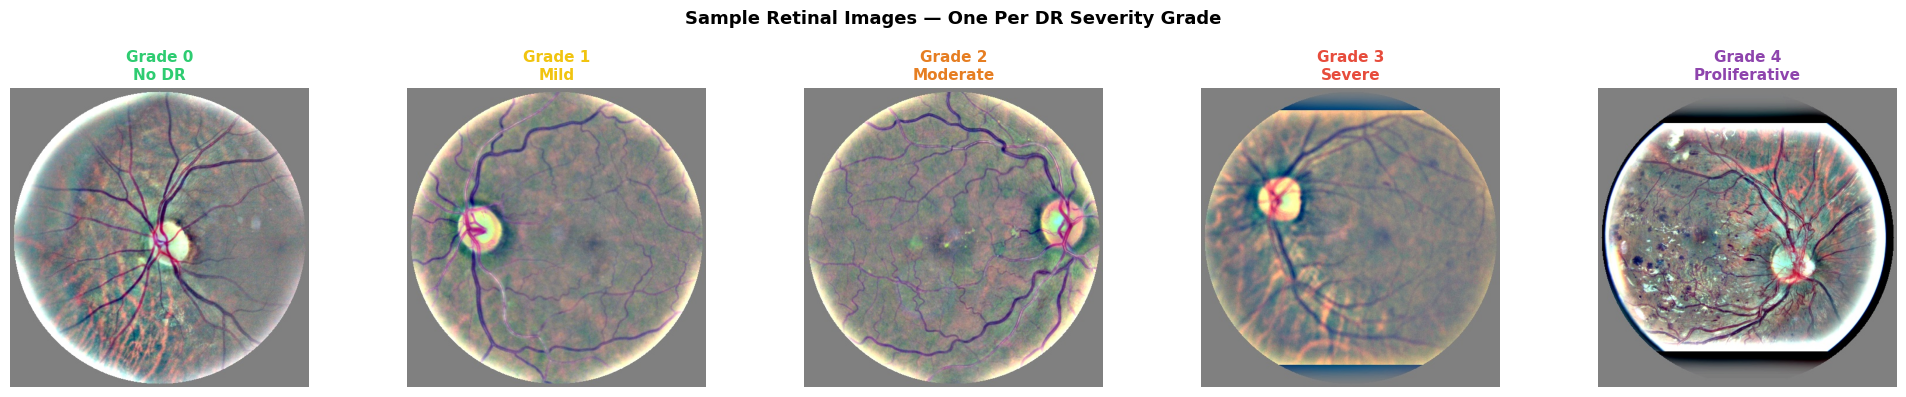

Sample images plot saved!


In [5]:
# ============================================================
# CELL 5 — Sample images per DR grade
# ============================================================

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle("Sample Retinal Images — One Per DR Severity Grade\n",
             fontsize=13, fontweight="bold")

colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#8e44ad"]

for grade in range(5):
    # Get first image of this grade
    subset = df[df["level"] == grade]
    img_name = subset.iloc[0]["image"]

    for ext in [".jpeg", ".jpg", ".png"]:
        img_path = os.path.join(IMAGE_DIR, img_name + ext)
        if os.path.exists(img_path):
            break

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    axes[grade].imshow(image)
    axes[grade].set_title(f"Grade {grade}\n{CLASS_NAMES[grade]}",
                          fontsize=11, fontweight="bold",
                          color=colors[grade])
    axes[grade].axis("off")

    # Add coloured border
    for spine in axes[grade].spines.values():
        spine.set_edgecolor(colors[grade])
        spine.set_linewidth(3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/sample_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sample images plot saved!")

## Dataset, Transforms, and Stratified Split

The dataset class loads image paths and labels from the CSV file. Training images use augmentation, while validation images use deterministic preprocessing.

A stratified train/validation split is applied so that both splits keep similar proportions of all five DR grades. This is especially important for minority classes such as Severe and Proliferative DR. A weighted sampler is then used on the training split to further reduce the effect of class imbalance during mini-batch sampling.


In [6]:
# ============================================================
# CELL 6 — Dataset class, transforms, and stratified split
# ============================================================

# Training uses stochastic augmentation to improve generalisation.
# Validation uses only deterministic resizing and normalisation so that
# evaluation reflects model performance rather than random augmentation noise.
def get_transforms(image_size=224, mode="train"):
    if mode == "train":
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(45),
            transforms.ColorJitter(brightness=0.2, contrast=0.2,
                                   saturation=0.1, hue=0.05),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225]),
        ])

    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])


class DRDataset(Dataset):
    """
    PyTorch Dataset for diabetic retinopathy image grading.

    The CSV file contains the image identifier and DR severity label:
    - image: filename without extension
    - level: integer class label from 0 to 4

    The code checks common image extensions and stores only files that exist
    in IMAGE_DIR. Each sample is returned as an RGB PIL image transformed into
    the tensor format expected by Swin Tiny.
    """
    def __init__(self, csv_path, image_dir, transform=None):
        self.df        = pd.read_csv(csv_path)
        self.image_dir = image_dir
        self.transform = transform
        self.samples   = []

        for _, row in self.df.iterrows():
            img_name = str(row["image"])
            label    = int(row["level"])

            # The Kaggle data can be stored with different extensions after
            # preprocessing, so try the expected options in order.
            for ext in [".jpeg", ".jpg", ".png"]:
                img_path = os.path.join(image_dir, img_name + ext)
                if os.path.exists(img_path):
                    self.samples.append((img_path, label))
                    break

        print(f"Dataset loaded: {len(self.samples)} images")
        counts = Counter(label for _, label in self.samples)
        for i, name in enumerate(CLASS_NAMES):
            print(f"  Class {i} ({name}): {counts.get(i, 0)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = Image.fromarray(image)

        if self.transform:
            image = self.transform(image)

        return image, label

    def get_labels(self):
        """Return labels in dataset index order; used for stratification."""
        return [label for _, label in self.samples]


class SubsetWithTransform(Dataset):
    """
    Wrap a Subset and apply a different transform.

    The base dataset is created with training transforms. This wrapper lets the
    validation subset reuse the same image paths and labels while applying the
    deterministic validation transform instead.
    """
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        original_idx = self.subset.indices[idx]
        img_path, label = self.subset.dataset.samples[original_idx]

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = Image.fromarray(image)

        if self.transform:
            image = self.transform(image)

        return image, label


def get_sampler(labels):
    """
    Build a sqrt inverse-frequency WeightedRandomSampler for the training set.

    Diabetic retinopathy grades are highly imbalanced. The square-root version
    increases minority-class sampling without making the sampler overly aggressive.
    """
    labels = np.asarray(labels, dtype=int)
    counts = np.bincount(labels, minlength=NUM_CLASSES)

    # Guard against division by zero if a future small subset misses a class.
    safe_counts    = np.maximum(counts, 1).astype(float)
    class_weights  = 1.0 / np.sqrt(safe_counts)
    sample_weights = [class_weights[label] for label in labels]

    return WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)


def print_split_distribution(name, labels):
    """Print class counts and percentages for a split."""
    counts = Counter(labels)
    total  = len(labels)
    print(f"\n{name} class distribution:")
    for i, class_name in enumerate(CLASS_NAMES):
        count = counts.get(i, 0)
        print(f"  Class {i} ({class_name}): {count} images ({count / total * 100:.1f}%)")


# Load the full dataset with training transforms. The validation subset is
# wrapped later to replace these with deterministic validation transforms.
print("Loading dataset...")
full_dataset = DRDataset(CSV_PATH, IMAGE_DIR,
                         transform=get_transforms(IMAGE_SIZE, "train"))

# Stratified splitting preserves the class proportions in both train and
# validation sets. This is important for DR grading because minority classes
# such as Severe and Proliferative DR are much rarer than No DR.
all_indices = np.arange(len(full_dataset))
all_labels_for_split = full_dataset.get_labels()
train_indices, val_indices = train_test_split(
    all_indices,
    test_size=VAL_SPLIT,
    random_state=SEED,
    stratify=all_labels_for_split,
)

train_ds = Subset(full_dataset, train_indices.tolist())
val_ds   = Subset(full_dataset, val_indices.tolist())

# Apply validation transforms only to the validation subset.
val_ds_clean = SubsetWithTransform(val_ds, get_transforms(IMAGE_SIZE, "val"))

# Keep training labels available for the sampler and loss weighting.
train_labels = [full_dataset.samples[i][1] for i in train_ds.indices]
val_labels   = [full_dataset.samples[i][1] for i in val_ds.indices]

print_split_distribution("Training", train_labels)
print_split_distribution("Validation", val_labels)

sampler = get_sampler(train_labels)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    drop_last=True,
)

val_loader = DataLoader(
    val_ds_clean,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
)

train_size = len(train_ds)
val_size   = len(val_ds)
print(f"\nTrain: {train_size} images | Val: {val_size} images")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")


Loading dataset...
Dataset loaded: 35126 images
  Class 0 (No DR): 25810
  Class 1 (Mild): 2443
  Class 2 (Moderate): 5292
  Class 3 (Severe): 873
  Class 4 (Proliferative): 708

Training class distribution:
  Class 0 (No DR): 21938 images (73.5%)
  Class 1 (Mild): 2077 images (7.0%)
  Class 2 (Moderate): 4498 images (15.1%)
  Class 3 (Severe): 742 images (2.5%)
  Class 4 (Proliferative): 602 images (2.0%)

Validation class distribution:
  Class 0 (No DR): 3872 images (73.5%)
  Class 1 (Mild): 366 images (6.9%)
  Class 2 (Moderate): 794 images (15.1%)
  Class 3 (Severe): 131 images (2.5%)
  Class 4 (Proliferative): 106 images (2.0%)

Train: 29857 images | Val: 5269 images
Train batches: 933 | Val batches: 165


## Model Definition

A pretrained Swin Tiny model is loaded and adapted for five-class DR grading by replacing the ImageNet classification head with a new task-specific classifier. Transfer learning allows the model to reuse visual features learned from a large image dataset.


In [7]:
# ============================================================
# CELL 7 — Model: Swin Tiny 224
# ============================================================

def build_swin_tiny_model(num_classes=5, dropout=0.3):
    """
    Swin Tiny — shifted-window Transformer for 224x224 image classification.

    Key innovation: shifted-window self-attention, which keeps computation
    efficient while allowing information to flow across local windows.

    Architecture:
    - Swin Tiny backbone (patch size 4, window size 7, image 224x224)
    - 4 hierarchical stages with shifted-window transformer blocks
    - Pretrained on ImageNet-1k

    For DR grading: pretrained backbone frozen initially, then
    fine-tuned with layer-wise learning rate decay.
    """
    model = SwinForImageClassification.from_pretrained(
        "microsoft/swin-tiny-patch4-window7-224",
        num_labels=num_classes,
        ignore_mismatched_sizes=True,
    )
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes)
    )
    return model


model = build_swin_tiny_model(NUM_CLASSES).to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: Swin Tiny patch4 window7 224")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable:,}")

[transformers] You passed `num_labels=5` which is incompatible to the `id2label` map of length `1000`.
Loading weights: 100%|██████████| 233/233 [00:00<00:00, 1495.45it/s]
[transformers] SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([5, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Model: Swin Tiny patch4 window7 224
Total parameters:     27,523,199
Trainable parameters: 27,523,199


## Loss Function, Optimiser, and Scheduler

Class-weighted cross entropy is used to give more importance to under-represented DR grades. The optimiser uses a smaller learning rate for the pretrained backbone and a larger learning rate for the new classifier head. A warmup plus cosine scheduler supports stable fine-tuning.


In [8]:
# ============================================================
# CELL 8 — Loss, optimiser, and scheduler
# ============================================================

# Class weights are calculated from the training split only. This avoids using
# validation-set label information while still compensating for class imbalance.
label_counts = [Counter(train_labels)[i] for i in range(NUM_CLASSES)]
print(f"Training label counts: {label_counts}")

# Square-root inverse-frequency weighting gives more importance to rare DR
# grades while avoiding unstable, excessively large weights.
counts_arr    = torch.tensor(label_counts, dtype=torch.float)
class_weights = 1.0 / torch.sqrt(counts_arr)
class_weights = (class_weights / class_weights.sum() * NUM_CLASSES).to(device)
print(f"Class weights: {class_weights.cpu().numpy().round(3)}")

# Label smoothing reduces overconfidence and can improve generalisation.
criterion = nn.CrossEntropyLoss(weight=class_weights,
                                label_smoothing=LABEL_SMOOTHING)

# The pretrained Swin backbone uses a smaller learning rate, while the newly
# initialised classifier head is allowed to adapt faster to the DR classes.
head_params     = list(model.classifier.parameters())
head_ids        = set(id(p) for p in head_params)
backbone_params = [p for p in model.parameters() if id(p) not in head_ids]

optimizer = AdamW([
    {"params": backbone_params, "lr": LR_BACKBONE},
    {"params": head_params,     "lr": LR_HEAD},
], weight_decay=WEIGHT_DECAY)

# Warmup stabilises the first few epochs; cosine decay then gradually lowers
# the learning rate for fine-tuning.
warmup    = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=3)
cosine    = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS-3, eta_min=1e-7)
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[3])

# Mixed precision speeds up training on CUDA-capable GPUs and reduces memory use.
scaler = GradScaler("cuda")

print("Loss, optimiser and scheduler ready!")


Training label counts: [21938, 2077, 4498, 742, 602]
Class weights: [0.279 0.906 0.616 1.516 1.683]
Loss, optimiser and scheduler ready!


## Training and Validation Functions

These helper functions define one training epoch and one validation pass. Training uses mixed precision, gradient accumulation, and gradient clipping to improve efficiency and stability. Validation stores both predicted labels and probabilities for later metrics such as QWK, F1, ROC curves, and AUC.


In [9]:
# ============================================================
# CELL 9 — Training and validation functions
# ============================================================

def train_one_epoch(model, loader, optimizer, criterion, device, scaler):
    """Run one full training epoch and return loss, predictions, and labels."""
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    optimizer.zero_grad()

    for step, (images, labels) in enumerate(tqdm(loader, desc="  Train", leave=False)):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Automatic mixed precision reduces GPU memory use and speeds up training.
        with autocast("cuda"):
            outputs = model(pixel_values=images).logits
            loss    = criterion(outputs, labels) / ACCUMULATION

        scaler.scale(loss).backward()

        # Gradient accumulation simulates a larger effective batch size. Clipping
        # protects the fine-tuning process from unstable gradient spikes.
        if (step + 1) % ACCUMULATION == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += loss.item() * ACCUMULATION
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), np.array(all_preds), np.array(all_labels)


@torch.no_grad()
def validate(model, loader, criterion, device):
    """Evaluate the model without gradient updates."""
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []

    for images, labels in tqdm(loader, desc="  Val  ", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast("cuda"):
            outputs = model(pixel_values=images).logits
            loss    = criterion(outputs, labels)

        # Store probabilities as well as hard labels so ROC-AUC can be computed later.
        total_loss += loss.item()
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return (total_loss / len(loader),
            np.array(all_preds),
            np.array(all_labels),
            np.array(all_probs))


print("Training functions defined!")


Training functions defined!


## Training Loop and Early Stopping

The model is trained for a maximum number of epochs, but early stopping monitors validation Quadratic Weighted Kappa (QWK). QWK is a suitable primary metric for DR grading because it accounts for the ordered nature of severity levels.


In [10]:
# ============================================================
# CELL 10 — Training loop with early stopping
# ============================================================

best_qwk      = -1.0
no_improve    = 0
train_losses, val_losses, val_qwks = [], [], []
val_preds_final = val_labels_final = val_probs_final = None

print(f"Starting training — max {NUM_EPOCHS} epochs, early stopping patience={PATIENCE}\n")

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"Epoch {epoch}/{NUM_EPOCHS}")

    train_loss, _, _ = train_one_epoch(
        model, train_loader, optimizer, criterion, device, scaler)
    val_loss, val_preds, val_labels_ep, val_probs = validate(
        model, val_loader, criterion, device)
    scheduler.step()

    qwk      = cohen_kappa_score(val_labels_ep, val_preds, weights="quadratic")
    f1_macro = f1_score(val_labels_ep, val_preds, average="macro", zero_division=0)
    acc      = (val_preds == val_labels_ep).mean()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_qwks.append(qwk)

    print(f"  Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}")
    print(f"  QWK: {qwk:.4f} | F1 macro: {f1_macro:.4f} | Acc: {acc:.4f}")

    if qwk > best_qwk:
        best_qwk            = qwk
        no_improve          = 0
        val_preds_final     = val_preds
        val_labels_final    = val_labels_ep
        val_probs_final     = val_probs
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "qwk": qwk,
        }, f"{OUTPUT_DIR}/checkpoints/best_swin_tiny.pth")
        print(f"  ✓ New best QWK {best_qwk:.4f} — saved!")
    else:
        no_improve += 1
        print(f"  No improvement ({no_improve}/{PATIENCE})")
        if no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

print(f"\nTraining complete! Best QWK: {best_qwk:.4f}")

Starting training — max 30 epochs, early stopping patience=7

Epoch 1/30


  Train loss: 1.7174 | Val loss: 1.8504
  QWK: 0.0636 | F1 macro: 0.1214 | Acc: 0.1368
  ✓ New best QWK 0.0636 — saved!
Epoch 2/30


  Train loss: 1.6173 | Val loss: 1.7560
  QWK: 0.1951 | F1 macro: 0.1796 | Acc: 0.1771
  ✓ New best QWK 0.1951 — saved!
Epoch 3/30


  Train loss: 1.4696 | Val loss: 1.6140
  QWK: 0.4400 | F1 macro: 0.3515 | Acc: 0.4904
  ✓ New best QWK 0.4400 — saved!
Epoch 4/30


  Train loss: 1.3945 | Val loss: 1.5875
  QWK: 0.4771 | F1 macro: 0.3718 | Acc: 0.4976
  ✓ New best QWK 0.4771 — saved!
Epoch 5/30


...

  Train loss: 1.2055 | Val loss: 1.5132
  QWK: 0.5620 | F1 macro: 0.4508 | Acc: 0.5462
  No improvement (3/7)
Epoch 18/30


  Train loss: 1.2020 | Val loss: 1.5056
  QWK: 0.5807 | F1 macro: 0.4581 | Acc: 0.5652
  No improvement (4/7)
Epoch 19/30


  Train loss: 1.2007 | Val loss: 1.5081
  QWK: 0.5722 | F1 macro: 0.4590 | Acc: 0.5510
  No improvement (5/7)
Epoch 20/30


  Train loss: 1.1868 | Val loss: 1.5066
  QWK: 0.5821 | F1 macro: 0.4619 | Acc: 0.5677
  No improvement (6/7)
Epoch 21/30


  Train loss: 1.1908 | Val loss: 1.5070
  QWK: 0.5832 | F1 macro: 0.4635 | Acc: 0.5696
  No improvement (7/7)

Early stopping at epoch 21.

Training complete! Best QWK: 0.6004


## Training Curves

The loss curves and validation QWK curve are plotted to inspect learning behaviour across epochs and to check whether the model improves consistently before early stopping.


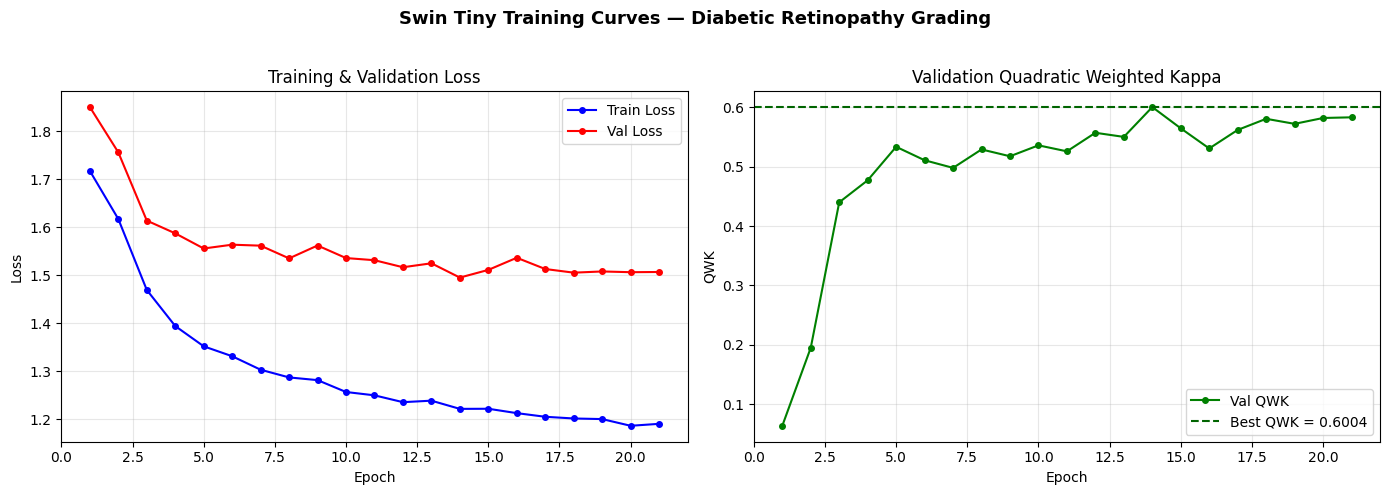

Training curves saved!


In [13]:
# ============================================================
# CELL 11 — Training curves
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Swin Tiny Training Curves — Diabetic Retinopathy Grading\n",
             fontsize=13, fontweight="bold")

epochs_range = range(1, len(train_losses) + 1)

axes[0].plot(epochs_range, train_losses, "b-o", markersize=4, label="Train Loss")
axes[0].plot(epochs_range, val_losses,   "r-o", markersize=4, label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training & Validation Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, val_qwks, "g-o", markersize=4, label="Val QWK")
axes[1].axhline(y=best_qwk, color="darkgreen", linestyle="--",
                label=f"Best QWK = {best_qwk:.4f}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("QWK")
axes[1].set_title("Validation Quadratic Weighted Kappa")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Training curves saved!")

## Confusion Matrix

The confusion matrix shows where the model makes correct predictions and where it confuses neighbouring or distant severity grades. Both raw counts and normalised values are useful for interpreting class-wise performance.


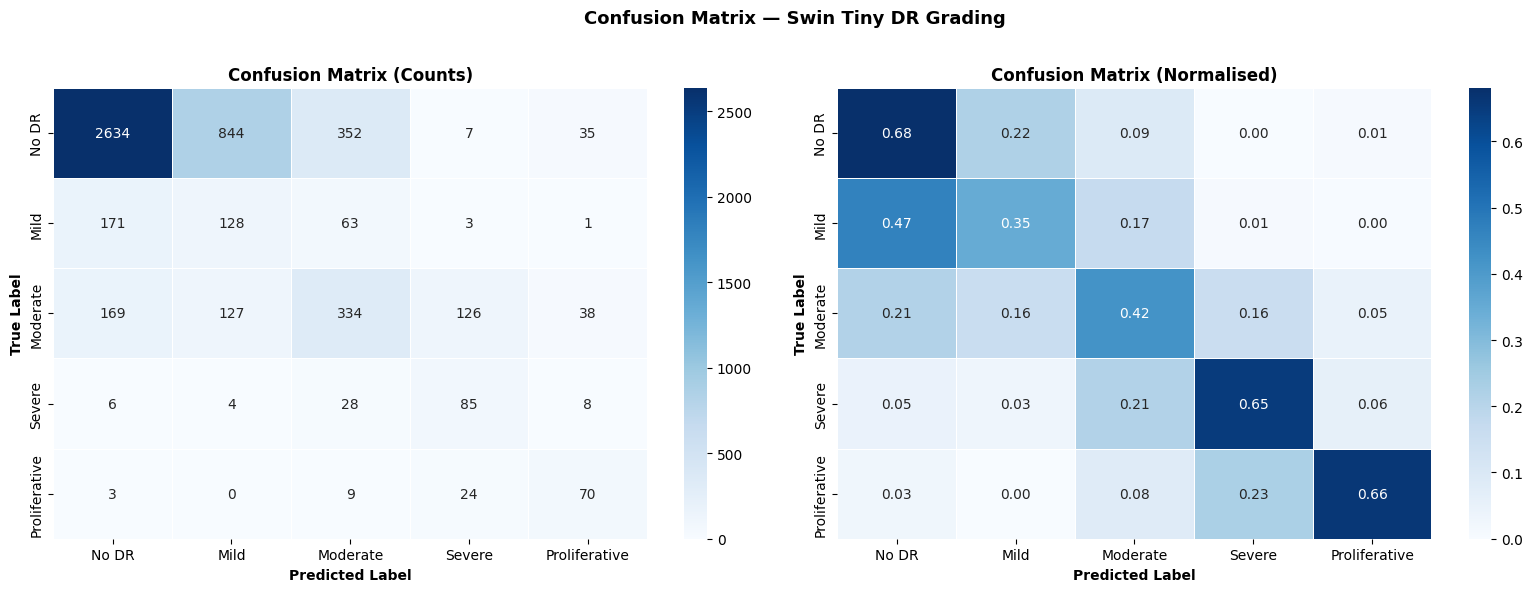


── Classification Report ──
               precision    recall  f1-score   support

        No DR       0.88      0.68      0.77      3872
         Mild       0.12      0.35      0.17       366
     Moderate       0.42      0.42      0.42       794
       Severe       0.35      0.65      0.45       131
Proliferative       0.46      0.66      0.54       106

     accuracy                           0.62      5269
    macro avg       0.45      0.55      0.47      5269
 weighted avg       0.74      0.62      0.66      5269

Overall Accuracy : 0.6170 (61.70%)
Best QWK         : 0.6004
Macro F1         : 0.4721


In [16]:
# ============================================================
# CELL 12 — Confusion matrix
# ============================================================

cm      = confusion_matrix(val_labels_final, val_preds_final)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Confusion Matrix — Swin Tiny DR Grading\n",
             fontsize=13, fontweight="bold")

for ax, data, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ["Confusion Matrix (Counts)", "Confusion Matrix (Normalised)"],
    ["d", ".2f"]
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5)
    ax.set_xlabel("Predicted Label", fontweight="bold")
    ax.set_ylabel("True Label", fontweight="bold")
    ax.set_title(title, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Print classification report
print("\n── Classification Report ──")
print(classification_report(val_labels_final, val_preds_final,
                             target_names=CLASS_NAMES, zero_division=0))
acc = (val_preds_final == val_labels_final).mean()
print(f"Overall Accuracy : {acc:.4f} ({acc*100:.2f}%)")
print(f"Best QWK         : {best_qwk:.4f}")
print(f"Macro F1         : {f1_score(val_labels_final, val_preds_final, average='macro', zero_division=0):.4f}")

## ROC Curves and AUC

One-vs-rest ROC curves are generated for each class using the stored validation probabilities. AUC provides an additional view of separability for each DR grade.


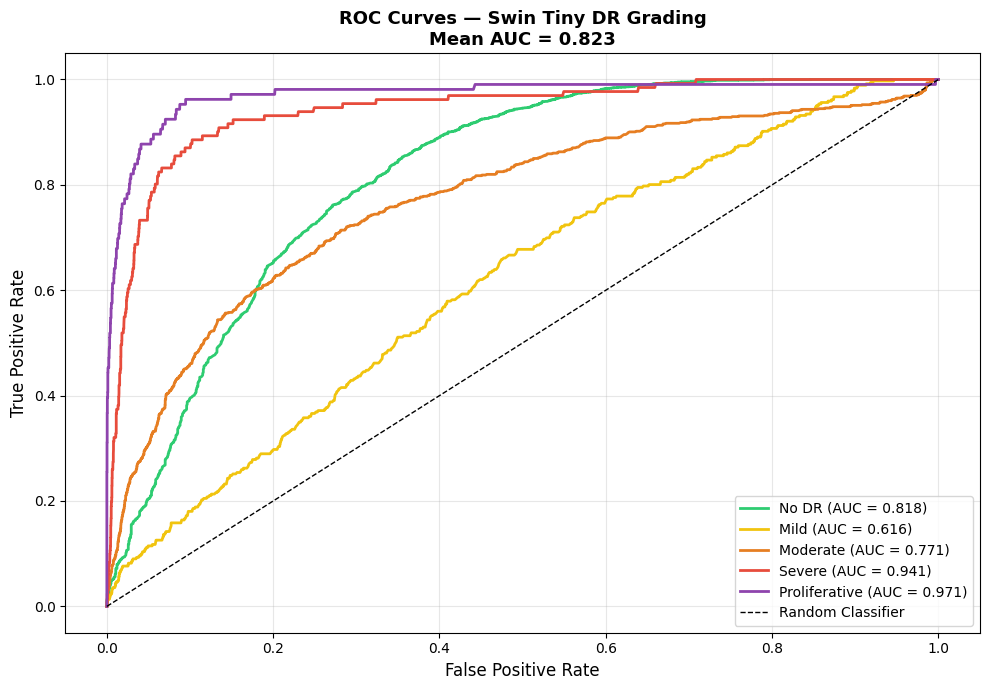

ROC curves saved! Mean AUC: 0.8233


In [17]:
# ============================================================
# CELL 13 — ROC Curve + AUC
# ============================================================

y_true_bin = label_binarize(val_labels_final, classes=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(10, 7))
colors  = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#8e44ad"]

auc_scores = []
for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], val_probs_final[:, i])
    auc_val     = auc(fpr, tpr)
    auc_scores.append(auc_val)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{name} (AUC = {auc_val:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(f"ROC Curves — Swin Tiny DR Grading\n"
             f"Mean AUC = {np.mean(auc_scores):.3f}",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"ROC curves saved! Mean AUC: {np.mean(auc_scores):.4f}")

## Per-Class Precision, Recall, and F1

Per-class metrics highlight whether performance is balanced across all severity grades. This is particularly useful for imbalanced medical image classification, where accuracy alone can hide poor minority-class performance.


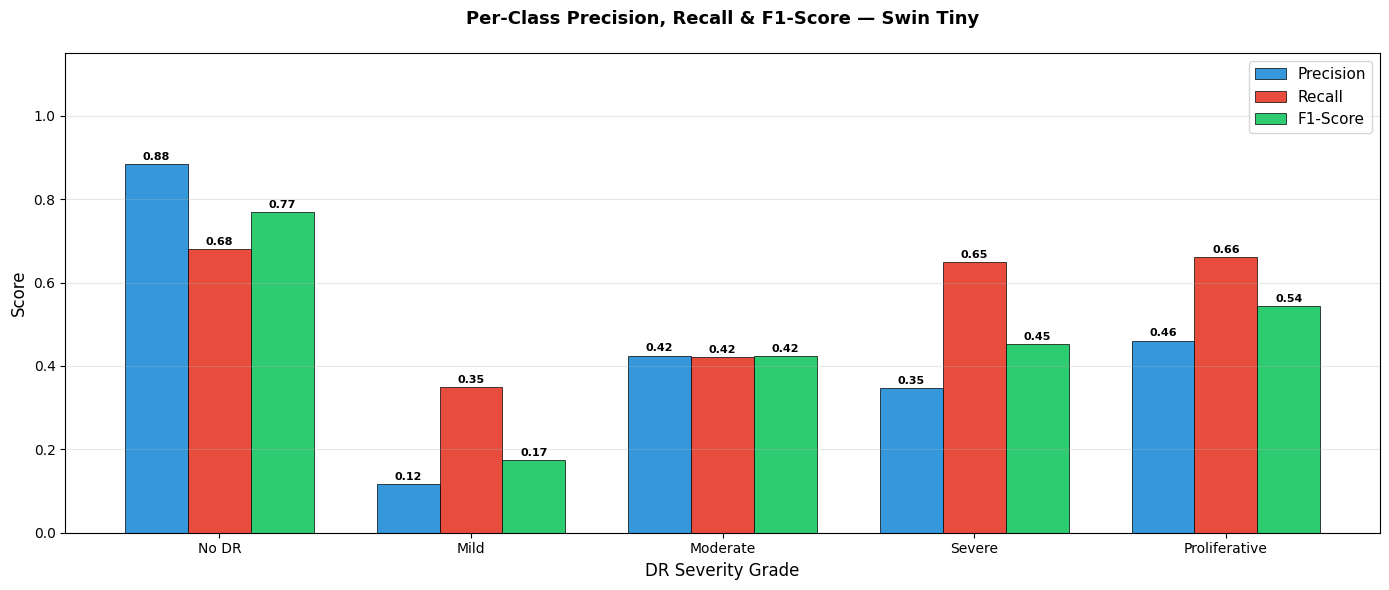

Per-class metrics chart saved!


In [18]:
# ============================================================
# CELL 14 — Per-class F1, Precision, Recall bar chart
# ============================================================

report = classification_report(val_labels_final, val_preds_final,
                                target_names=CLASS_NAMES,
                                output_dict=True, zero_division=0)

metrics_data = {
    "Precision": [report[c]["precision"] for c in CLASS_NAMES],
    "Recall":    [report[c]["recall"]    for c in CLASS_NAMES],
    "F1-Score":  [report[c]["f1-score"]  for c in CLASS_NAMES],
}

x      = np.arange(len(CLASS_NAMES))
width  = 0.25
colors = ["#3498db", "#e74c3c", "#2ecc71"]

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, vals) in enumerate(metrics_data.items()):
    bars = ax.bar(x + i*width, vals, width, label=metric,
                  color=colors[i], edgecolor="black", linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", fontsize=8, fontweight="bold")

ax.set_xlabel("DR Severity Grade", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Per-Class Precision, Recall & F1-Score — Swin Tiny\n",
             fontsize=13, fontweight="bold")
ax.set_xticks(x + width)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/per_class_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Per-class metrics chart saved!")

## Grad-CAM Visualisation

Grad-CAM heatmaps are used to visualise the image regions that influence the model predictions. This provides qualitative interpretability and helps assess whether the network focuses on clinically relevant retinal regions.


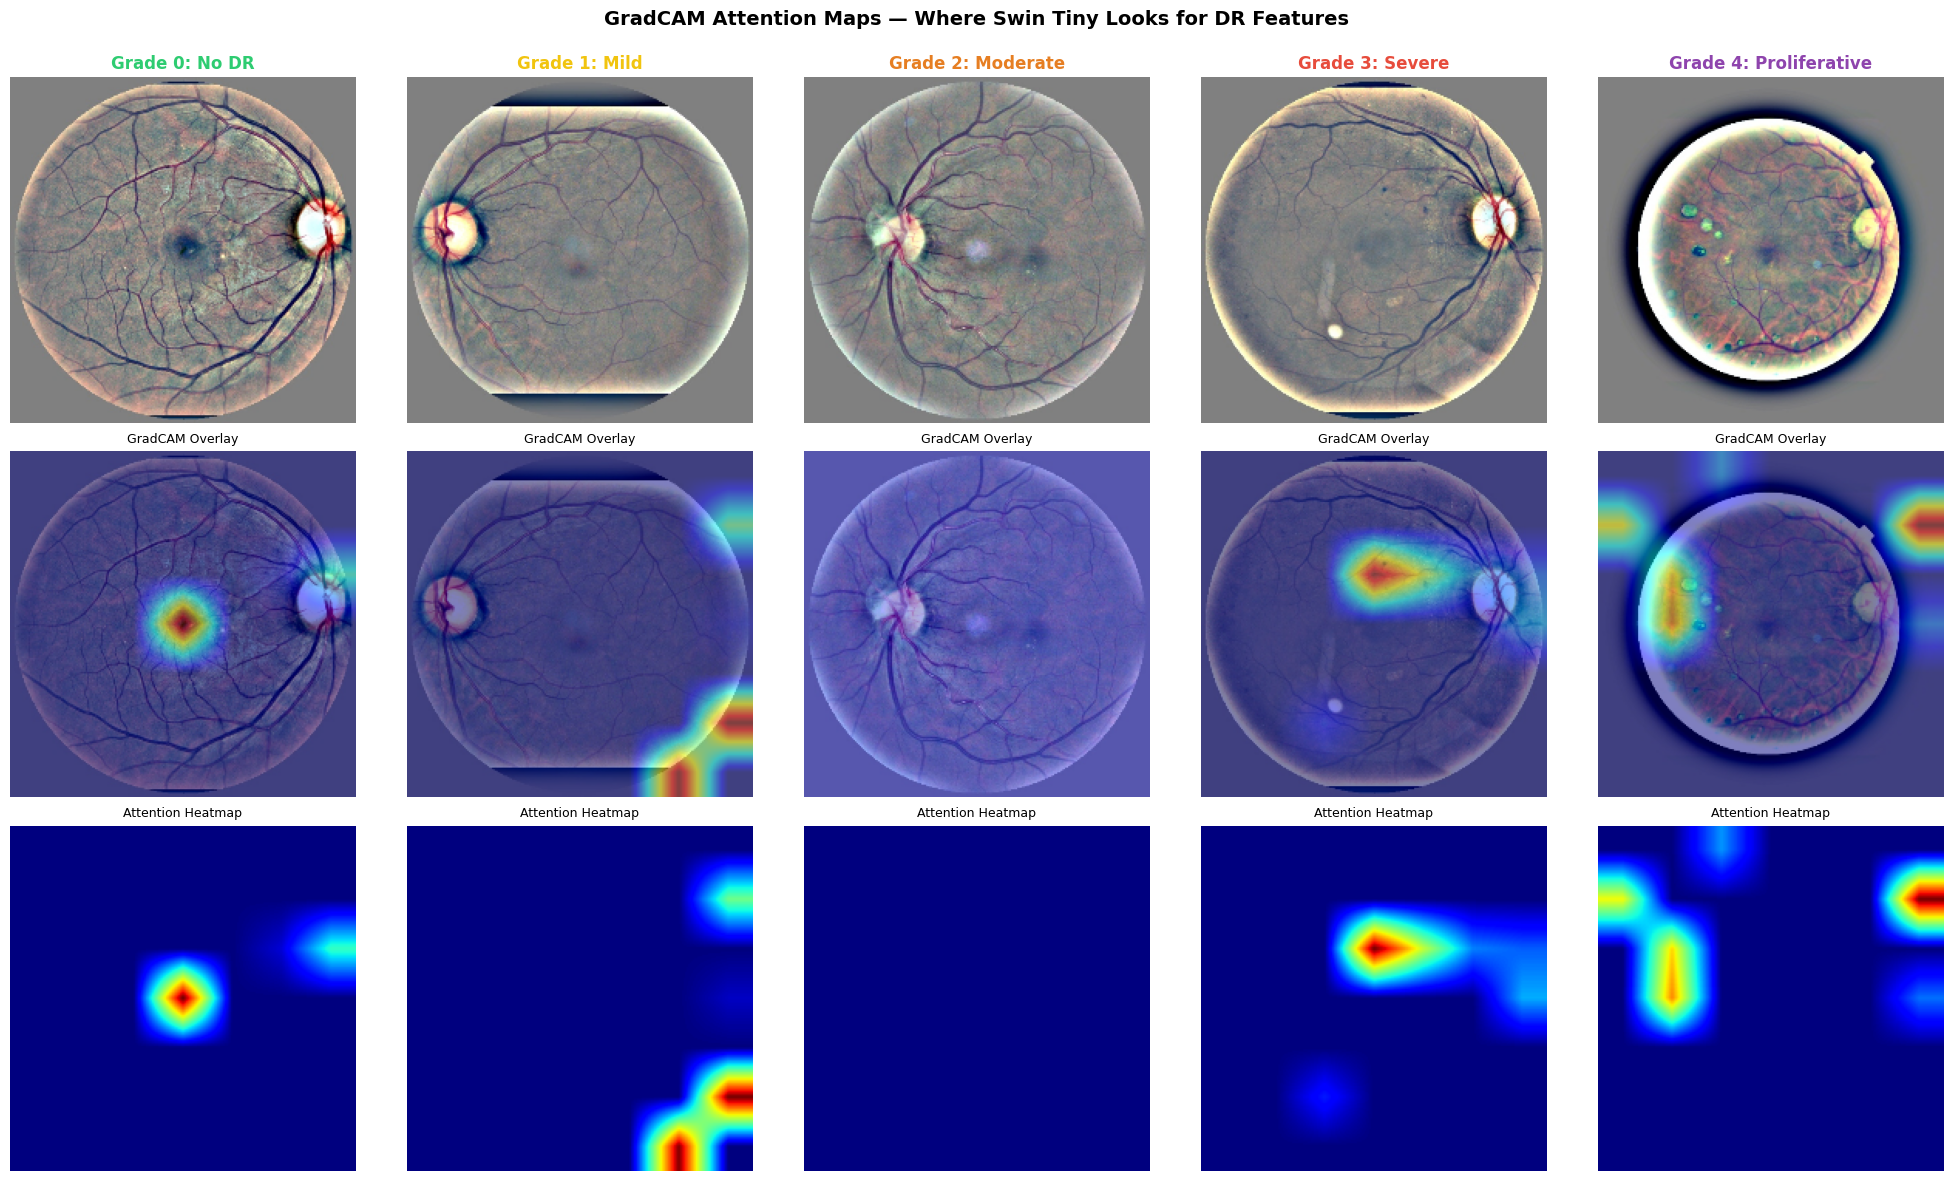

GradCAM heatmaps saved!


In [19]:
# ============================================================
# CELL 15 — GradCAM Attention Heatmaps (Swin Tiny)
# ============================================================

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Load best checkpoint
ckpt = torch.load(f"{OUTPUT_DIR}/checkpoints/best_swin_tiny.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

# Wrapper to make Swin Tiny output a plain tensor for GradCAM
class SwinTinyWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return self.model(pixel_values=x).logits

wrapped_model = SwinTinyWrapper(model)
wrapped_model.eval()

# Target layer — last Swin Tiny transformer block
target_layers = [model.swin.encoder.layers[-1].blocks[-1].layernorm_before]

# Reshape transform for Swin Tiny final feature tokens
def reshape_transform(tensor, height=7, width=7):
    result = tensor.reshape(
        tensor.size(0), height, width, tensor.size(2)
    )
    result = result.transpose(2, 3).transpose(1, 2)
    return result

cam = GradCAM(
    model=wrapped_model,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

# Get one image per class
val_transform = get_transforms(IMAGE_SIZE, "val")
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle("GradCAM Attention Maps — Where Swin Tiny Looks for DR Features\n",
             fontsize=14, fontweight="bold")

colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#8e44ad"]

for grade in range(5):
    subset   = df[df["level"] == grade]
    img_name = subset.iloc[3]["image"]

    for ext in [".jpeg", ".jpg", ".png"]:
        img_path = os.path.join(IMAGE_DIR, img_name + ext)
        if os.path.exists(img_path):
            break

    # Load original image
    orig = cv2.imread(img_path)
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    orig_resized = cv2.resize(orig, (IMAGE_SIZE, IMAGE_SIZE))
    orig_float   = orig_resized.astype(np.float32) / 255.0

    # Prepare tensor
    input_tensor = val_transform(
        Image.fromarray(orig_resized)
    ).unsqueeze(0).to(device)

    # Generate CAM
    targets   = [ClassifierOutputTarget(grade)]
    grayscale = cam(input_tensor=input_tensor, targets=targets)
    cam_image = show_cam_on_image(orig_float, grayscale[0], use_rgb=True)

    # Row 1 — original
    axes[0, grade].imshow(orig_resized)
    axes[0, grade].set_title(f"Grade {grade}: {CLASS_NAMES[grade]}",
                              fontweight="bold", color=colors[grade])
    axes[0, grade].axis("off")

    # Row 2 — GradCAM overlay
    axes[1, grade].imshow(cam_image)
    axes[1, grade].set_title("GradCAM Overlay", fontsize=9)
    axes[1, grade].axis("off")

    # Row 3 — heatmap only
    axes[2, grade].imshow(grayscale[0], cmap="jet")
    axes[2, grade].set_title("Attention Heatmap", fontsize=9)
    axes[2, grade].axis("off")

# Row labels
for row, label in enumerate(["Original Image", "GradCAM Overlay", "Attention Heatmap"]):
    axes[row, 0].set_ylabel(label, fontsize=11, fontweight="bold",
                             rotation=90, labelpad=10)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/gradcam_heatmaps.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("GradCAM heatmaps saved!")

## Final Results Summary

The final section reports the main validation metrics, per-class F1 scores, imbalance-handling methods, and saved output files. These values provide a compact summary for submission and comparison with other experiments.


In [20]:
# ============================================================
# CELL 16 — Final results summary
# ============================================================

acc      = (val_preds_final == val_labels_final).mean()
f1_macro = f1_score(val_labels_final, val_preds_final, average="macro", zero_division=0)
f1_per   = f1_score(val_labels_final, val_preds_final, average=None,   zero_division=0)

print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("Model: Swin Tiny patch4 window7 224")
print("Dataset: Processed Kaggle DR Dataset (35,126 images)")
print("=" * 60)
print(f"Best QWK (primary metric) : {best_qwk:.4f}")
print(f"Overall Accuracy          : {acc:.4f} ({acc*100:.2f}%)")
print(f"Macro F1                  : {f1_macro:.4f}")
print(f"Mean AUC                  : {np.mean(auc_scores):.4f}")
print("-" * 60)
print("Per-class F1 scores:")
for i, (name, score) in enumerate(zip(CLASS_NAMES, f1_per)):
    print(f"  Class {i} ({name:15s}): {score:.4f}")
print("-" * 60)
print("Imbalance handling strategies:")
print("  1. Sqrt inverse frequency WeightedRandomSampler")
print("  2. Sqrt inverse frequency class weights in CrossEntropy")
print("  3. Label smoothing = 0.1")
print("  4. Layer-wise learning rate decay")
print("  5. LR warmup 3 epochs + cosine annealing")
print("=" * 60)
print(f"\nAll outputs saved to: {OUTPUT_DIR}/plots/")
print("Files saved:")
for f in os.listdir(f"{OUTPUT_DIR}/plots"):
    print(f"  {f}")

FINAL RESULTS SUMMARY
Model: Swin Tiny patch4 window7 224
Dataset: Processed Kaggle DR Dataset (35,126 images)
Best QWK (primary metric) : 0.6004
Overall Accuracy          : 0.6170 (61.70%)
Macro F1                  : 0.4721
Mean AUC                  : 0.8233
------------------------------------------------------------
Per-class F1 scores:
  Class 0 (No DR          ): 0.7685
  Class 1 (Mild           ): 0.1743
  Class 2 (Moderate       ): 0.4228
  Class 3 (Severe         ): 0.4521
  Class 4 (Proliferative  ): 0.5426
------------------------------------------------------------
Imbalance handling strategies:
  1. Sqrt inverse frequency WeightedRandomSampler
  2. Sqrt inverse frequency class weights in CrossEntropy
  3. Label smoothing = 0.1
  4. Layer-wise learning rate decay
  5. LR warmup 3 epochs + cosine annealing

All outputs saved to: outputs_final/plots/
Files saved:
  per_class_metrics.png
  confusion_matrix.png
  gradcam_heatmaps.png
  roc_curves.png
  training_curves.png
  clas